<a href="https://colab.research.google.com/github/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/blob/main/Static/M02_02_Organizaci%C3%B3n_preparaci%C3%B3n_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://github.com/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/raw/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>

<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Introducción a la Ciencia de Datos</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Introducción a la Ciencia de Datos
## Módulo 2: Organización y preparación de datos

### Notebook 2: Selección y manipulación de datos


En el notebook anterior aprendimos a importar una serie climática, explorar la estructura de un `DataFrame`, trabajar con fechas e identificar datos faltantes.

En este notebook aprenderemos a **seleccionar, filtrar, ordenar y modificar datos** utilizando Pandas.

Trabajaremos nuevamente con la serie diaria de precipitación de la estación **Bernardo O'Higgins, Chillán**, obtenida desde el Explorador Climático CR2.

Al finalizar este notebook podrás:

- seleccionar columnas de un DataFrame;

- seleccionar filas utilizando posiciones o etiquetas;

- utilizar `.loc[]` e `.iloc[]`;

- filtrar observaciones mediante condiciones;

- combinar varias condiciones;

- seleccionar periodos específicos;

- ordenar datos;

- crear nuevas variables;

- modificar y eliminar columnas.

## 1. Importar las librerías

Utilizaremos nuevamente la librería `pandas`, que contiene las principales herramientas para manipular datos tabulares.

También utilizaremos `matplotlib` para realizar algunas visualizaciones simples que nos ayuden a comprobar los resultados de nuestros filtros.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Cargar los datos

Comenzaremos cargando nuevamente el archivo utilizado en el notebook anterior.

Recuerda que Google Colab funciona en un entorno temporal. Por esta razón, cuando iniciamos una nueva sesión debemos volver a cargar los archivos que utilizaremos.

Ejecuta la siguiente celda y selecciona el archivo:

`BernardoOHigginsChillan.xlsx`

In [2]:
from google.colab import files

uploaded = files.upload()

Saving BernardoOHigginsChillan.xlsx to BernardoOHigginsChillan.xlsx


## 3. Leer el archivo con Pandas

El archivo contiene una hoja llamada `Serie`.

Utilizaremos la función `read_excel()` de Pandas para importar los datos.

In [5]:
datos = pd.read_excel("BernardoOHigginsChillan.xlsx", sheet_name="Serie")
datos.head()

,agno,mes,dia,valor
0,1950,1,1,0.0
1,1950,1,2,0.0
2,1950,1,3,0.0
3,1950,1,4,0.0
4,1950,1,5,0.0


Antes de continuar, realizaremos nuevamente algunas operaciones de preparación utilizadas en el notebook anterior.

Crearemos una columna de fecha y cambiaremos los nombres `agno` y `valor` por nombres más fáciles de interpretar.

In [6]:
datos["fecha"] = pd.to_datetime(
    dict(
        year=datos["agno"],
        month=datos["mes"],
        day=datos["dia"]
    )
)

datos = datos.rename(columns={
    "agno": "anio",
    "valor": "precipitacion_mm"
})

datos = datos[
    ["fecha", "anio", "mes", "dia", "precipitacion_mm"]
]

datos.head()

,fecha,anio,mes,dia,precipitacion_mm
0,1950-01-01,1950,1,1,0.0
1,1950-01-02,1950,1,2,0.0
2,1950-01-03,1950,1,3,0.0
3,1950-01-04,1950,1,4,0.0
4,1950-01-05,1950,1,5,0.0


## 3. Seleccionar columnas

Un DataFrame puede contener muchas variables. En determinadas etapas del análisis solamente necesitaremos trabajar con algunas de ellas.

Podemos seleccionar una columna utilizando su nombre entre corchetes.

In [7]:
datos["precipitacion_mm"]

,precipitacion_mm
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
25532,4.2
25533,0.0
25534,0.0
25535,0.0


Al seleccionar una sola columna, Pandas devuelve una estructura denominada `Series`.

Podemos comprobarlo utilizando `type()`.

In [8]:
type(datos["precipitacion_mm"])

pandas.core.series.Series

También podemos seleccionar varias columnas.

En ese caso debemos proporcionar una lista con los nombres de las columnas que queremos conservar.

In [9]:
datos[["fecha", "precipitacion_mm"]].head()

,fecha,precipitacion_mm
0,1950-01-01,0.0
1,1950-01-02,0.0
2,1950-01-03,0.0
3,1950-01-04,0.0
4,1950-01-05,0.0


## 4. Seleccionar filas mediante `iloc`

Pandas permite seleccionar registros según su **posición** dentro del DataFrame utilizando `.iloc[]`.

Al igual que las listas de Python, las posiciones comienzan en `0`.

Por lo tanto:

- posición `0` → primera fila;
- posición `1` → segunda fila;
- posición `2` → tercera fila.

In [10]:
datos.iloc[0]

,0
fecha,1950-01-01 00:00:00
anio,1950
mes,1
dia,1
precipitacion_mm,0.0


In [11]:
datos.iloc[0:5]

,fecha,anio,mes,dia,precipitacion_mm
0,1950-01-01,1950,1,1,0.0
1,1950-01-02,1950,1,2,0.0
2,1950-01-03,1950,1,3,0.0
3,1950-01-04,1950,1,4,0.0
4,1950-01-05,1950,1,5,0.0


La expresión `0:5` selecciona desde la posición `0` hasta antes de la posición `5`.

Por lo tanto, obtenemos las primeras cinco observaciones.

In [12]:
datos.iloc[0:5, [0, 4]]

,fecha,precipitacion_mm
0,1950-01-01,0.0
1,1950-01-02,0.0
2,1950-01-03,0.0
3,1950-01-04,0.0
4,1950-01-05,0.0


En este ejemplo:

- `0:5` selecciona las primeras cinco filas.
- `[0, 4]` selecciona la primera y quinta columna.

`iloc` trabaja siempre utilizando **posiciones numéricas**.

## 5. Seleccionar datos mediante `.loc`

Mientras `.iloc[]` utiliza posiciones, `.loc[]` permite seleccionar información utilizando **etiquetas o nombres de columnas**.

Esto suele hacer que el código sea más fácil de leer.

In [13]:
datos.loc[0:4, ["fecha", "precipitacion_mm"]]

,fecha,precipitacion_mm
0,1950-01-01,0.0
1,1950-01-02,0.0
2,1950-01-03,0.0
3,1950-01-04,0.0
4,1950-01-05,0.0


Observa una diferencia importante:

Con `.loc[]`, el límite final también se incluye.

Por esta razón:

`datos.loc[0:4]`

incluye las filas con índice `0`, `1`, `2`, `3` y `4`.

## 6. Filtrar datos mediante condiciones

Una de las operaciones más útiles en ciencia de datos consiste en seleccionar solamente aquellas observaciones que cumplen una determinada condición.

Por ejemplo, podemos preguntar:

**¿Qué días registraron precipitación mayor a 20 mm?**

In [15]:
datos["precipitacion_mm"] > 20

,precipitacion_mm
0,False
1,False
2,False
3,False
4,False
...,...
25532,False
25533,False
25534,False
25535,False


El resultado es una serie de valores `True` y `False`.

- `True` indica que la condición se cumple.
- `False` indica que la condición no se cumple.

Podemos utilizar esta condición para seleccionar solamente las filas donde el resultado es `True`.

In [16]:
lluvias_mayores_20 = datos[
    datos["precipitacion_mm"] > 20
]

lluvias_mayores_20.head()

,fecha,anio,mes,dia,precipitacion_mm
95,1950-04-06,1950,4,6,38.4
107,1950-04-18,1950,4,18,22.5
110,1950-04-21,1950,4,21,46.5
130,1950-05-11,1950,5,11,36.4
131,1950-05-12,1950,5,12,21.7


In [17]:
len(lluvias_mayores_20)

1142

Podemos modificar fácilmente el umbral de selección.

Por ejemplo, seleccionemos días con precipitación igual o superior a 50 mm.

In [18]:
datos[
    datos["precipitacion_mm"] >= 50
].head(10)

,fecha,anio,mes,dia,precipitacion_mm
166,1950-06-16,1950,6,16,51.7
176,1950-06-26,1950,6,26,84.0
312,1950-11-09,1950,11,9,50.6
503,1951-05-19,1951,5,19,79.2
525,1951-06-10,1951,6,10,88.3
526,1951-06-11,1951,6,11,52.5
563,1951-07-18,1951,7,18,60.7
861,1952-05-11,1952,5,11,53.7
1230,1953-05-15,1953,5,15,112.3
1231,1953-05-16,1953,5,16,68.4


## 7. Combinar varias condiciones

También podemos seleccionar observaciones que cumplan más de una condición.

En Pandas utilizaremos principalmente:

- `&` para **y**;
- `|` para **o**.

Cada condición debe escribirse entre paréntesis.

Por ejemplo:

**¿Qué días del año 2025 tuvieron precipitación superior a 20 mm?**

In [20]:
datos_2025_lluvia = datos[
    (datos["anio"] == 2025) &
    (datos["precipitacion_mm"] > 20)
]

datos_2025_lluvia

,fecha,anio,mes,dia,precipitacion_mm
25046,2025-03-29,2025,3,29,40.8
25103,2025-05-25,2025,5,25,32.0
25121,2025-06-12,2025,6,12,32.8
25123,2025-06-14,2025,6,14,40.4
25169,2025-07-30,2025,7,30,25.6
25171,2025-08-01,2025,8,1,20.2


En este caso, ambas condiciones deben cumplirse simultáneamente:

1. el año debe ser 2025;
2. la precipitación debe ser superior a 20 mm.

También podemos seleccionar información según el mes.

Por ejemplo:

**¿Qué observaciones corresponden a junio de 2025?**

In [19]:
junio_2025 = datos[
    (datos["anio"] == 2025) &
    (datos["mes"] == 6)
]

junio_2025.head()

,fecha,anio,mes,dia,precipitacion_mm
25110,2025-06-01,2025,6,1,0.0
25111,2025-06-02,2025,6,2,0.0
25112,2025-06-03,2025,6,3,0.0
25113,2025-06-04,2025,6,4,0.0
25114,2025-06-05,2025,6,5,0.2


## 8. Filtrar utilizando fechas

Como nuestra columna `fecha` utiliza el tipo `datetime`, podemos seleccionar periodos utilizando directamente las fechas.

Por ejemplo, seleccionaremos las observaciones entre el 1 de junio y el 31 de agosto de 2025.

In [21]:
periodo = datos[
    (datos["fecha"] >= "2025-06-01") &
    (datos["fecha"] <= "2025-08-31")
]

periodo.head()

,fecha,anio,mes,dia,precipitacion_mm
25110,2025-06-01,2025,6,1,0.0
25111,2025-06-02,2025,6,2,0.0
25112,2025-06-03,2025,6,3,0.0
25113,2025-06-04,2025,6,4,0.0
25114,2025-06-05,2025,6,5,0.2


In [22]:
periodo.tail()

,fecha,anio,mes,dia,precipitacion_mm
25196,2025-08-27,2025,8,27,0.2
25197,2025-08-28,2025,8,28,0.0
25198,2025-08-29,2025,8,29,0.2
25199,2025-08-30,2025,8,30,0.2
25200,2025-08-31,2025,8,31,1.6


Esta forma de selección será especialmente útil cuando trabajemos con series temporales.

No necesitamos conocer el número de fila correspondiente a cada fecha: podemos indicar directamente el periodo que queremos analizar.

Una vez seleccionado un subconjunto de datos, podemos aplicar las mismas operaciones que utilizamos sobre el DataFrame completo.

Por ejemplo:

**¿Cuál fue la precipitación diaria máxima durante junio, julio y agosto de 2025?**

In [23]:
periodo["precipitacion_mm"].max()

40.4

In [24]:
periodo.loc[
    periodo["precipitacion_mm"].idxmax()
]

,25123
fecha,2025-06-14 00:00:00
anio,2025
mes,6
dia,14
precipitacion_mm,40.4


## 9. Ordenar datos

Los datos pueden ordenarse utilizando `sort_values()`.

Por ejemplo, podemos ordenar toda la serie desde los días con mayor precipitación hacia los días con menor precipitación.

In [26]:
datos_ordenados = datos.sort_values(
    by="precipitacion_mm",
    ascending=False
)

datos_ordenados.head(10)

,fecha,anio,mes,dia,precipitacion_mm
16614,2002-02-26,2002,2,26,153.7
1633,1960-06-20,1960,6,20,148.0
5727,1972-05-07,1972,5,7,145.3
14843,1997-04-22,1997,4,22,139.1
11042,1986-11-25,1986,11,25,136.3
1631,1960-06-18,1960,6,18,129.0
13029,1992-05-04,1992,5,4,127.3
6507,1974-06-26,1974,6,26,123.5
13028,1992-05-03,1992,5,3,118.1
13060,1992-06-04,1992,6,4,115.9


El argumento:

`ascending=False`

indica que queremos ordenar los valores de mayor a menor.

Si utilizamos `ascending=True`, el orden será de menor a mayor.

In [27]:
datos.nlargest(
    10,
    "precipitacion_mm"
)

,fecha,anio,mes,dia,precipitacion_mm
16614,2002-02-26,2002,2,26,153.7
1633,1960-06-20,1960,6,20,148.0
5727,1972-05-07,1972,5,7,145.3
14843,1997-04-22,1997,4,22,139.1
11042,1986-11-25,1986,11,25,136.3
1631,1960-06-18,1960,6,18,129.0
13029,1992-05-04,1992,5,4,127.3
6507,1974-06-26,1974,6,26,123.5
13028,1992-05-03,1992,5,3,118.1
13060,1992-06-04,1992,6,4,115.9


La función `nlargest()` permite obtener directamente los registros con los valores más altos de una variable.

En este ejemplo obtuvimos los **10 días con mayor precipitación** de toda la serie.

## 10. Crear nuevas variables

También podemos generar nuevas columnas a partir de las variables existentes.

Por ejemplo, podemos crear una variable sencilla que indique si un día fue seco o presentó precipitación.

In [28]:
datos["dia_con_lluvia"] = (
    datos["precipitacion_mm"] > 0
)

datos.head()

,fecha,anio,mes,dia,precipitacion_mm,dia_con_lluvia
0,1950-01-01,1950,1,1,0.0,False
1,1950-01-02,1950,1,2,0.0,False
2,1950-01-03,1950,1,3,0.0,False
3,1950-01-04,1950,1,4,0.0,False
4,1950-01-05,1950,1,5,0.0,False


La nueva variable contiene valores lógicos:

- `True`: se registró precipitación.
- `False`: no se registró precipitación.

Más adelante aprenderemos a definir criterios más específicos para clasificar eventos.

In [29]:
datos["estado"] = "Seco"

datos.loc[
    datos["precipitacion_mm"] > 0,
    "estado"
] = "Lluvia"

datos.head()

,fecha,anio,mes,dia,precipitacion_mm,dia_con_lluvia,estado
0,1950-01-01,1950,1,1,0.0,False,Seco
1,1950-01-02,1950,1,2,0.0,False,Seco
2,1950-01-03,1950,1,3,0.0,False,Seco
3,1950-01-04,1950,1,4,0.0,False,Seco
4,1950-01-05,1950,1,5,0.0,False,Seco


En este caso:

1. inicialmente asignamos `"Seco"` a todas las observaciones;
2. luego utilizamos `.loc[]` para cambiar a `"Lluvia"` aquellas filas donde la precipitación fue mayor que cero.

Esto muestra que `.loc[]` también puede utilizarse para **modificar datos**, no solamente para seleccionarlos.


## 11. Eliminar columnas

Durante el procesamiento podemos crear variables temporales o encontrar columnas que ya no necesitamos.

La función `drop()` permite eliminar filas o columnas.

In [30]:
datos_simplificados = datos.drop(
    columns=["dia_con_lluvia"]
)

datos_simplificados.head()

,fecha,anio,mes,dia,precipitacion_mm,estado
0,1950-01-01,1950,1,1,0.0,Seco
1,1950-01-02,1950,1,2,0.0,Seco
2,1950-01-03,1950,1,3,0.0,Seco
3,1950-01-04,1950,1,4,0.0,Seco
4,1950-01-05,1950,1,5,0.0,Seco


En este ejemplo creamos un **nuevo DataFrame** sin la columna `dia_con_lluvia`.

El DataFrame original `datos` permanece sin cambios.

Esta práctica es recomendable mientras estamos aprendiendo, porque evita modificar accidentalmente nuestros datos originales.

## 12. Reiniciar el índice

Después de filtrar datos, los índices originales se mantienen.

Veamos nuevamente las observaciones con precipitación superior a 50 mm.

In [31]:
eventos = datos[
    datos["precipitacion_mm"] > 50
]

eventos.head()

,fecha,anio,mes,dia,precipitacion_mm,dia_con_lluvia,estado
166,1950-06-16,1950,6,16,51.7,True,Lluvia
176,1950-06-26,1950,6,26,84.0,True,Lluvia
312,1950-11-09,1950,11,9,50.6,True,Lluvia
503,1951-05-19,1951,5,19,79.2,True,Lluvia
525,1951-06-10,1951,6,10,88.3,True,Lluvia


Observa que el índice de la primera columna puede presentar valores como `166`, `176`, `312`, etc.

Estos corresponden a las posiciones originales dentro del DataFrame completo.

Podemos crear un índice consecutivo utilizando `reset_index()`.

In [32]:
eventos = eventos.reset_index(
    drop=True
)

eventos.head()

,fecha,anio,mes,dia,precipitacion_mm,dia_con_lluvia,estado
0,1950-06-16,1950,6,16,51.7,True,Lluvia
1,1950-06-26,1950,6,26,84.0,True,Lluvia
2,1950-11-09,1950,11,9,50.6,True,Lluvia
3,1951-05-19,1951,5,19,79.2,True,Lluvia
4,1951-06-10,1951,6,10,88.3,True,Lluvia


## 13. Visualizar un subconjunto

Para comprobar nuestro proceso de selección, podemos visualizar únicamente la precipitación durante 2025.

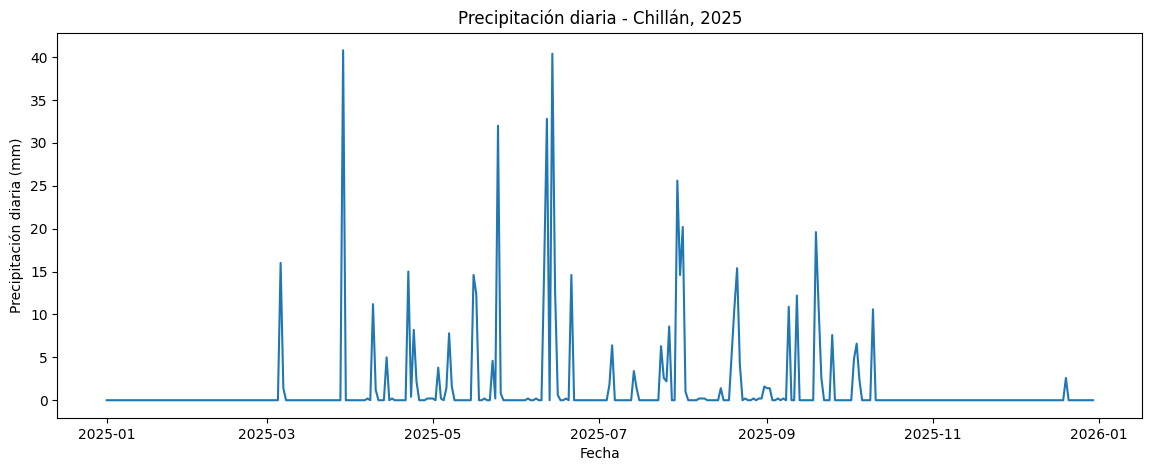

In [33]:
datos_2025 = datos[
    datos["anio"] == 2025
]

plt.figure(figsize=(14, 5))

plt.plot(
    datos_2025["fecha"],
    datos_2025["precipitacion_mm"]
)

plt.xlabel("Fecha")
plt.ylabel("Precipitación diaria (mm)")
plt.title(
    "Precipitación diaria - Chillán, 2025"
)

plt.show()


# En este notebook aprendimos...

En este notebook utilizamos Pandas para manipular una serie de datos reales.

Aprendimos a:

- seleccionar una o varias columnas;
- seleccionar filas mediante `.iloc[]`;
- utilizar `.loc[]`;
- filtrar datos mediante condiciones;
- combinar varias condiciones;
- seleccionar periodos utilizando fechas;
- ordenar observaciones;
- identificar los valores más altos;
- crear nuevas variables;
- modificar valores utilizando `.loc[]`;
- eliminar columnas;
- reiniciar índices después de realizar filtros.

Estas operaciones constituyen herramientas fundamentales para preparar bases de datos antes de realizar análisis estadísticos o construir modelos.

# Actividad práctica

Utilizando la segunda serie de precipitación proporcionada por el docente, realiza las siguientes actividades.

## 1. Importación y preparación

1. Importa el archivo de precipitación en Google Colab.
2. Identifica la hoja que contiene la serie de datos.
3. Construye una única variable de fecha a partir de las columnas de año, mes y día.
4. Convierte la variable `fecha` al tipo `datetime`.
5. Renombra la variable de precipitación como:

`precipitacion_mm`

## 2. Construcción del DataFrame final

Prepara un nuevo DataFrame que contenga únicamente:

- `fecha` como índice;
- `precipitacion_mm` como única columna.

El resultado esperado debe tener una estructura similar a:

| fecha | precipitacion_mm |
|---|---:|
| 2025-01-01 | 0.0 |
| 2025-01-02 | 4.2 |
| 2025-01-03 | 0.0 |

La columna `fecha` debe corresponder al **índice del DataFrame**.

## 3. Exploración y selección

6. Muestra las primeras y últimas observaciones del DataFrame.
7. Determina el número total de registros.
8. Identifica los días con precipitación superior a 20 mm.
9. Identifica los días con precipitación superior a 50 mm.
10. Obtén los 10 días con mayor precipitación de toda la serie.
11. Determina la precipitación diaria máxima y la fecha en que ocurrió.

## 4. Selección temporal

12. Selecciona solamente los registros correspondientes al año 2025.
13. Selecciona el periodo de invierno de 2025, correspondiente a los meses de **junio, julio y agosto (JJA)**.
14. Determina la precipitación diaria máxima registrada durante JJA de 2025 e identifica la fecha en que ocurrió.

## 5. Visualización

15. Realiza un gráfico de la **precipitación diaria durante el invierno (JJA) de 2025** para la estación asignada.

El gráfico debe incluir:

- fecha en el eje x;
- precipitación diaria en mm en el eje y;
- título indicando el nombre de la estación y el periodo;
- unidades de precipitación correctamente identificadas.
